# EDA y limpieza de vuelos

Objetivo: clasificar si un vuelo llegará con al menos 15 minutos de atraso,
usando datos conocidos antes de salir. El alcance son vuelos que completaron su ruta.
Este notebook explica y revisa los resultados del script `eda_limpieza.py`.
La limpieza completa ya fue ejecutada; el notebook no vuelve a recorrer los 5,8 millones de registros.
Fuente: [USDOT en Kaggle](https://www.kaggle.com/datasets/usdot/flight-delays).
La entrega final de Cloud Computing también necesita modelo, API, entorno, pruebas y GitHub.

## 1. Cargar bibliotecas y localizar el proyecto
Usamos pandas para tablas, NumPy para operaciones numéricas y Matplotlib para gráficos.

In [1]:
from pathlib import Path
from collections import Counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd()
if not (BASE / 'contrato_datos.json').exists():
    BASE = BASE.parent  # Si el notebook se abrió desde notebooks/.
contrato = json.loads((BASE / 'contrato_datos.json').read_text(encoding='utf-8'))
resumen = json.loads((BASE / 'reportes/resumen.json').read_text(encoding='utf-8'))
print('Filas originales:', resumen['filas_originales'])
print('Columnas originales:', resumen['columnas_originales'])
print('Predictores:', contrato['features'])

Filas originales: 5819079
Columnas originales: 31
Predictores: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE_MIN', 'SCHEDULED_TIME', 'DISTANCE']


## 2. Revisar faltantes antes de eliminar filas
Estos conteos corresponden al archivo original completo. Los campos de causas de atraso no aplican a todos los vuelos. No se reemplazan por cero.

In [2]:
nulos = pd.read_csv(BASE / 'reportes/nulos_original.csv', index_col=0)
print(nulos.sort_values('porcentaje', ascending=False).to_string())

                       nulos  porcentaje
CANCELLATION_REASON  5729195   98.455357
LATE_AIRCRAFT_DELAY  4755640   81.724960
WEATHER_DELAY        4755640   81.724960
AIRLINE_DELAY        4755640   81.724960
AIR_SYSTEM_DELAY     4755640   81.724960
SECURITY_DELAY       4755640   81.724960
ELAPSED_TIME          105071    1.805629
AIR_TIME              105071    1.805629
ARRIVAL_DELAY         105071    1.805629
WHEELS_ON              92513    1.589822
TAXI_IN                92513    1.589822
ARRIVAL_TIME           92513    1.589822
WHEELS_OFF             89047    1.530259
TAXI_OUT               89047    1.530259
DEPARTURE_TIME         86153    1.480526
DEPARTURE_DELAY        86153    1.480526
TAIL_NUMBER            14721    0.252978
SCHEDULED_TIME             6    0.000103
DESTINATION_AIRPORT        0    0.000000
DAY                        0    0.000000
DAY_OF_WEEK                0    0.000000
AIRLINE                    0    0.000000
FLIGHT_NUMBER              0    0.000000
MONTH           

## 3. Revisar los códigos de aeropuerto por mes
En octubre aparecen códigos numéricos. Los mantenemos como categorías diferenciadas, con prefijo BTS:, sin eliminar el mes ni inventar equivalencias con IATA.

In [3]:
print(pd.read_csv(BASE / 'reportes/meses_original.csv').to_string(index=False))

 MONTH  filas  origen_codigo_numerico
   1.0 469968                       0
   2.0 429191                       0
   3.0 504312                       0
   4.0 485151                       0
   5.0 496993                       0
   6.0 503897                       0
   7.0 520718                       0
   8.0 510536                       0
   9.0 464946                       0
  10.0 486165                  486165
  11.0 467972                       0
  12.0 479230                       0


## 4. Aplicar reglas explícitas de limpieza
La siguiente función es exactamente la utilizada por el script en cada bloque.
Primero excluye cancelados y desviados, luego registros sin etiqueta y después datos imposibles.
Cada fila se contabiliza una sola vez. La función se define aquí para estudiar el código;
el procesamiento completo y la detección de duplicados entre bloques están en `eda_limpieza.py`.

Antes de llamar la función, el script asigna SOURCE_ROW y detecta duplicados mediante huellas
de la fila completa. No elimina vuelos solo por compartir ruta o aerolínea.
La detección de 64 bits es una comprobación práctica con riesgo teórico de colisiones.

In [4]:
CATEGORICAS = contrato['categoricas']
NUMERICAS = contrato['numericas']
FEATURES = contrato['features']
OBJETIVO = contrato['target']

def limpiar_bloque(df, conteos):
    """Devuelve vuelos elegibles. Cada descarte se cuenta una sola vez."""
    df = df.copy()
    for col in CATEGORICAS:
        df[col] = df[col].str.strip().str.upper().replace('', pd.NA)

    def filtrar(mascara, motivo):
        nonlocal df
        mascara = mascara.fillna(False)
        conteos[motivo] += int((~mascara).sum())
        df = df.loc[mascara].copy()

    filtrar(df.CANCELLED.eq(0), 'cancelado_o_estado_invalido')
    filtrar(df.DIVERTED.eq(0), 'desviado_o_estado_invalido')
    filtrar(np.isfinite(df.ARRIVAL_DELAY), 'sin_atraso_observado')
    df['FLIGHT_DATE'] = pd.to_datetime(
        df[['YEAR', 'MONTH', 'DAY']].rename(
            columns={'YEAR':'year', 'MONTH':'month', 'DAY':'day'}), errors='coerce')
    filtrar(df.FLIGHT_DATE.notna(), 'fecha_invalida')
    filtrar(df.DAY_OF_WEEK.eq(df.FLIGHT_DATE.dt.dayofweek + 1), 'dia_semana_inconsistente')

    # 0530 representa 05:30; no equivale a 530 minutos.
    hora = df.SCHEDULED_DEPARTURE
    hora_valida = (hora.between(0, 2359) & hora.mod(100).lt(60)
                   & hora.mod(1).eq(0)) | hora.eq(2400)
    filtrar(hora_valida, 'hora_programada_invalida')
    hora = df.SCHEDULED_DEPARTURE
    df['SCHEDULED_DEPARTURE_MIN'] = (hora.floordiv(100) * 60 + hora.mod(100)).astype(int)
    # Se conserva 2400 como 1440: final del día programado, sin cambiar la fecha.
    filtrar(np.isfinite(df.DISTANCE) & df.DISTANCE.gt(0)
            & np.isfinite(df.SCHEDULED_TIME) & df.SCHEDULED_TIME.gt(0),
            'distancia_o_duracion_invalida')
    filtrar(df[CATEGORICAS].notna().all(axis=1), 'categoria_faltante')
    filtrar(df.AIRLINE.str.fullmatch(r'[A-Z0-9]{2}'), 'aerolinea_formato_invalido')
    for col in ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
        filtrar(df[col].str.fullmatch(r'[A-Z]{3}|\d{5}'), col.lower() + '_formato_invalido')
        # Conservamos ambos sistemas. No se inventa una equivalencia entre códigos.
        numerico = df[col].str.fullmatch(r'\d{5}')
        df[col] = np.where(numerico, 'BTS:' + df[col], 'IATA:' + df[col])
    df[OBJETIVO] = df.ARRIVAL_DELAY.ge(15).astype(int)
    for col in ['MONTH', 'DAY', 'DAY_OF_WEEK']:
        df[col] = df[col].astype(int)
    df['FLIGHT_DATE'] = df.FLIGHT_DATE.dt.strftime('%Y-%m-%d')
    return df[['SOURCE_ROW', 'FLIGHT_DATE'] + FEATURES + ['ARRIVAL_DELAY', OBJETIVO]]

## 5. Comprobar el resultado de cada regla
Los conteos se generan durante la limpieza, no se escribieron manualmente. La suma permite reconstruir el paso desde el original hasta el limpio.

In [5]:
auditoria = pd.read_csv(BASE / 'reportes/auditoria_limpieza.csv')
print(auditoria.to_string(index=False))
assert auditoria.filas_excluidas.sum() + resumen['filas_limpias'] == resumen['filas_originales']
print('Reconciliación de filas: correcta')

                               regla  filas_excluidas  filas_restantes
               duplicados_por_huella                0          5819079
         cancelado_o_estado_invalido            89884          5729195
          desviado_o_estado_invalido            15187          5714008
                sin_atraso_observado                0          5714008
                      fecha_invalida                0          5714008
            dia_semana_inconsistente                0          5714008
            hora_programada_invalida                0          5714008
       distancia_o_duracion_invalida                0          5714008
                  categoria_faltante                0          5714008
          aerolinea_formato_invalido                0          5714008
     origin_airport_formato_invalido                0          5714008
destination_airport_formato_invalido                0          5714008
Reconciliación de filas: correcta


## 6. Guardar, muestrear y separar
El script escribe `data/flights_limpio.csv` por bloques. Conserva una muestra uniforme de 100.000
filas con prioridades aleatorias y semilla 42. No toma las primeras 100.000 filas.
Después toma el 80% de cada clase como train y reserva el 20% como test.
La siguiente celda muestra la separación reproducida desde la muestra entregada.
Solo se consulta test para verificar la separación; no se exploran sus distribuciones ni métricas.

In [6]:
muestra = pd.read_csv(BASE / 'data/flights_muestra.csv')
grupos_train = []
for _, grupo in muestra.groupby(OBJETIVO):
    grupos_train.append(grupo.sample(frac=0.8, random_state=42))
train_reproducido = pd.concat(grupos_train).sort_values('SOURCE_ROW')
train = pd.read_csv(BASE / 'data/train.csv')
test_ids = pd.read_csv(BASE / 'data/test.csv', usecols=['SOURCE_ROW'])
assert train_reproducido.SOURCE_ROW.tolist() == train.SOURCE_ROW.tolist()
assert set(train.SOURCE_ROW).isdisjoint(test_ids.SOURCE_ROW)
assert len(train) + len(test_ids) == len(muestra)
print('Muestra:', len(muestra), '| Train:', len(train), '| Test:', len(test_ids))
del muestra, train_reproducido, grupos_train, test_ids

Muestra: 100000 | Train: 80000 | Test: 20000


## 7. Inspeccionar el archivo listo para modelar
Se mantienen categorías legibles. ARRIVAL_DELAY es solo auditoría: usarla como predictor revelaría la respuesta.

In [7]:
print(train.head().to_string(index=False))
print('Tipos de datos:', train.dtypes.to_string(), sep=chr(10))
print('Nulos:', train.isna().sum().to_string(), sep=chr(10))
print('Categorías:', train[CATEGORICAS].nunique().to_string(), sep=chr(10))

 SOURCE_ROW FLIGHT_DATE AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  MONTH  DAY  DAY_OF_WEEK  SCHEDULED_DEPARTURE_MIN  SCHEDULED_TIME  DISTANCE  ARRIVAL_DELAY  ARRIVAL_DELAY_15
         55  2015-01-01      B6       IATA:BQN            IATA:MCO      1    1            4                      259           174.0    1129.0           -7.0                 0
        219  2015-01-01      AA       IATA:LIT            IATA:DFW      1    1            4                      360            80.0     304.0          -10.0                 0
        467  2015-01-01      WN       IATA:CMH            IATA:ATL      1    1            4                      375           110.0     447.0          116.0                 1
        572  2015-01-01      EV       IATA:SCE            IATA:DTW      1    1            4                      385            87.0     301.0          -25.0                 0
        590  2015-01-01      UA       IATA:SFO            IATA:EWR      1    1            4                      390    

## 8. Estadísticas y valores extremos
Un atraso negativo significa llegada anticipada. No borramos atrasos extremos válidos: forman parte del problema. No se aplica IQR ni winsorización.

In [8]:
print(train[NUMERICAS + ['ARRIVAL_DELAY']].describe(percentiles=[.01,.25,.5,.75,.99]).T.to_string())

                           count        mean         std   min     1%     25%    50%     75%      99%     max
MONTH                    80000.0    6.559863    3.386626   1.0    1.0    4.00    7.0     9.0    12.00    12.0
DAY                      80000.0   15.713012    8.789435   1.0    1.0    8.00   16.0    23.0    31.00    31.0
DAY_OF_WEEK              80000.0    3.936025    1.989945   1.0    1.0    2.00    4.0     6.0     7.00     7.0
SCHEDULED_DEPARTURE_MIN  80000.0  808.274963  290.652124   2.0  325.0  556.75  805.0  1050.0  1367.01  1439.0
SCHEDULED_TIME           80000.0  142.098287   75.431943  20.0   44.0   86.00  123.0   174.0   377.00   683.0
DISTANCE                 80000.0  825.321688  608.606152  31.0  100.0  373.00  651.0  1065.0  2586.00  4983.0
ARRIVAL_DELAY            80000.0    4.346012   39.056793 -73.0  -35.0  -13.00   -5.0     8.0   164.00  1598.0


## 9. Balance de clases
El denominador es la muestra de entrenamiento. Una exactitud alta puede ocultar que el modelo nunca detecta atrasos.

                  vuelos  porcentaje
ARRIVAL_DELAY_15                    
0                  65062     81.3275
1                  14938     18.6725


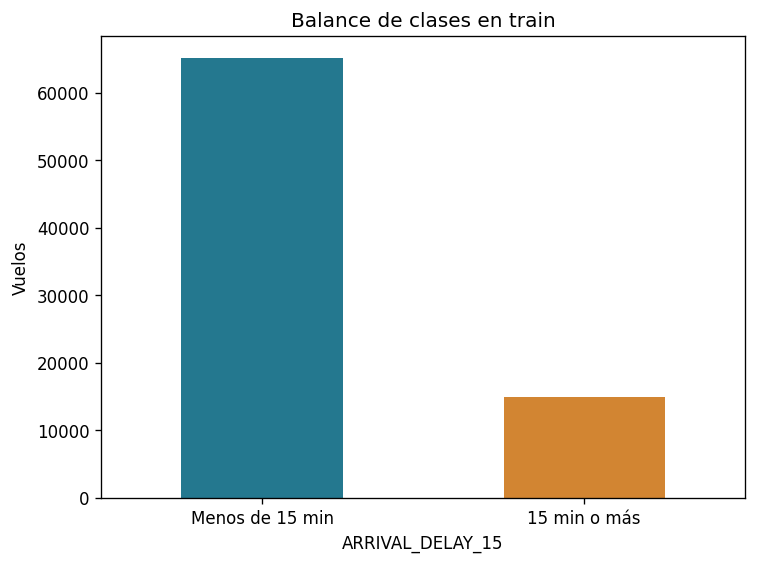

In [9]:
balance = train[OBJETIVO].value_counts().sort_index()
print(pd.DataFrame({'vuelos':balance, 'porcentaje':100*balance/len(train)}))
balance.rename(index={0:'Menos de 15 min',1:'15 min o más'}).plot.bar(rot=0, color=['#24788f','#d28532'])
plt.ylabel('Vuelos'); plt.title('Balance de clases en train'); plt.tight_layout(); plt.show()

En train hay 18.67% de atrasos. Conviene reportar F1 macro y recall de la clase atrasada, junto con precisión y matriz de confusión. Todavía no se han calculado métricas de un modelo.

## 10. Distribución del atraso
La primera vista conserva todo el rango. La segunda solo cambia la visualización; no borra filas del archivo.

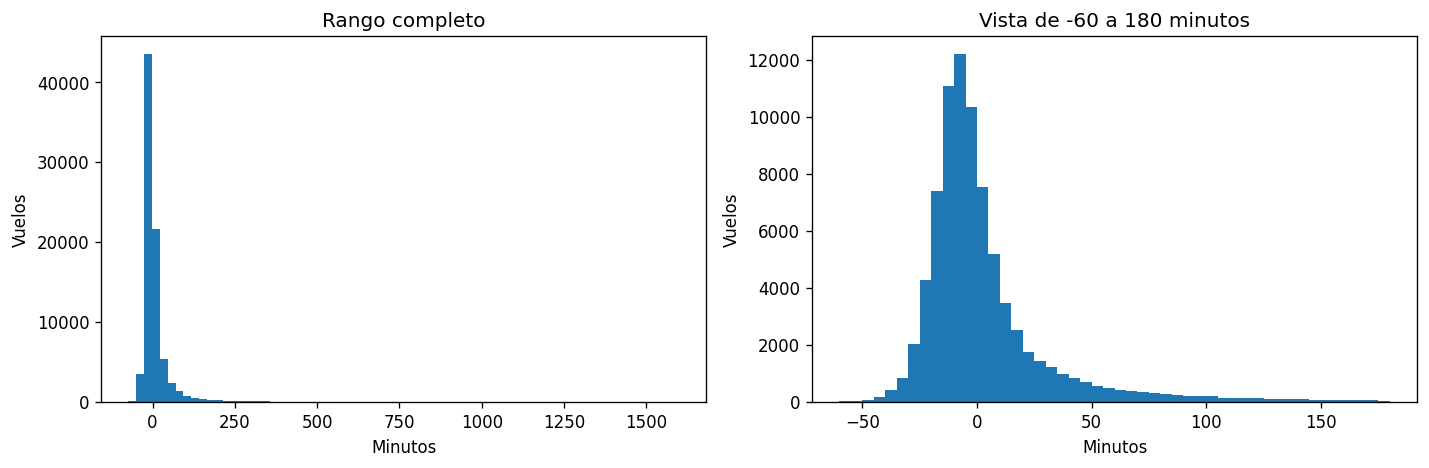

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
train.ARRIVAL_DELAY.plot.hist(bins=70, ax=axes[0])
train.loc[train.ARRIVAL_DELAY.between(-60,180), 'ARRIVAL_DELAY'].plot.hist(bins=48, ax=axes[1])
axes[0].set(title='Rango completo', xlabel='Minutos', ylabel='Vuelos')
axes[1].set(title='Vista de -60 a 180 minutos', xlabel='Minutos', ylabel='Vuelos')
plt.tight_layout(); plt.show()

## 11. Comparar aerolíneas y meses
La media de la etiqueta 0/1 es una proporción. Mostrar también el número de vuelos evita interpretar tasas sin su denominador. Las diferencias no prueban causalidad.

         vuelos  tasa_atraso
AIRLINE                     
AA         9971     0.173503
AS         2491     0.135688
B6         3571     0.229067
DL        12262     0.139129
EV         7843     0.196226
F9         1275     0.254118
HA         1077     0.129062
MQ         3887     0.221765
NK         1628     0.302211
OO         7963     0.187869
UA         7037     0.201506
US         2705     0.205915
VX          835     0.190419
WN        17455     0.192495
       vuelos  tasa_atraso
MONTH                     
1        6347     0.216323
2        5610     0.236898
3        6872     0.197614
4        6625     0.170113
5        6836     0.172908
6        6949     0.234854
7        7326     0.208982
8        7214     0.190324
9        6471     0.127801
10       6787     0.132459
11       6427     0.151081
12       6536     0.204406


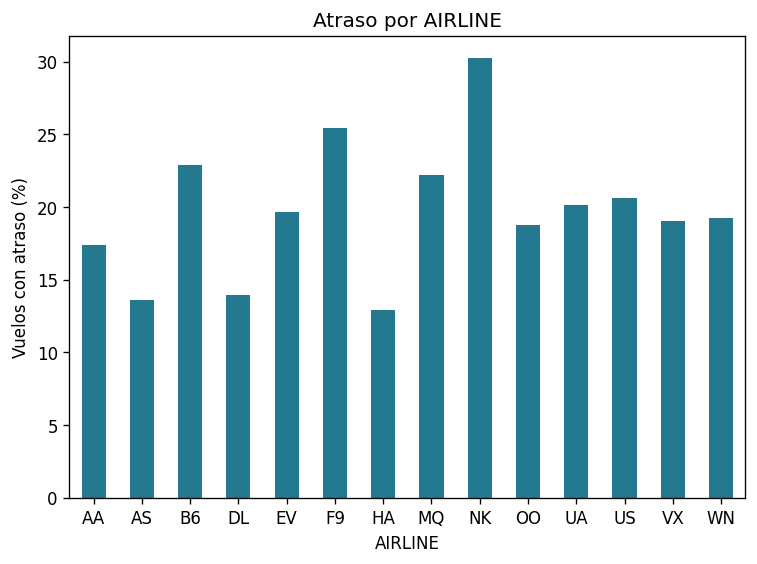

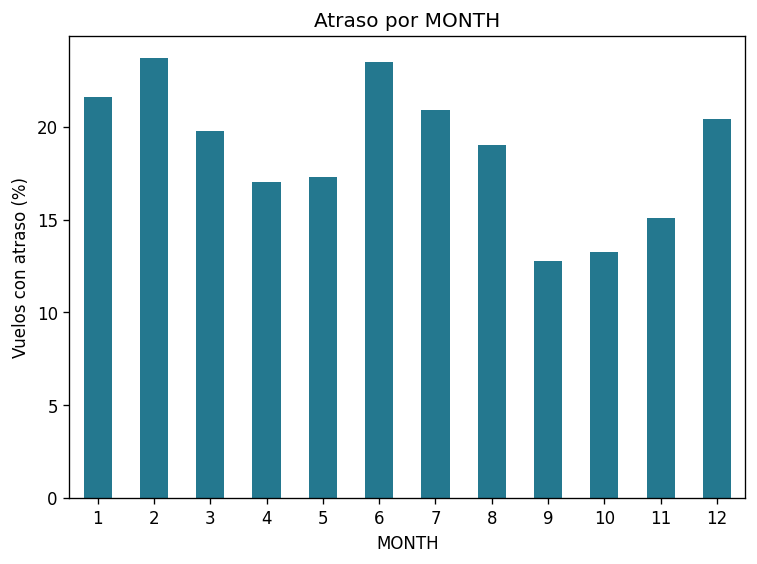

In [11]:
for variable in ['AIRLINE', 'MONTH']:
    tabla = train.groupby(variable)[OBJETIVO].agg(vuelos='size', tasa_atraso='mean')
    print(tabla.to_string())
    (100*tabla.tasa_atraso).plot.bar(rot=0, color='#24788f')
    plt.ylabel('Vuelos con atraso (%)'); plt.title('Atraso por ' + variable)
    plt.tight_layout(); plt.show()

## 12. Escalas y relaciones numéricas
Distancia está en millas; duración, salida programada y atraso están en minutos. No se interpretan los códigos de aeropuerto como números.

                         DISTANCE  ...  ARRIVAL_DELAY_15
DISTANCE                    1.000  ...            -0.001
SCHEDULED_TIME              0.984  ...            -0.002
SCHEDULED_DEPARTURE_MIN    -0.003  ...             0.139
ARRIVAL_DELAY_15           -0.001  ...             1.000

[4 rows x 4 columns]


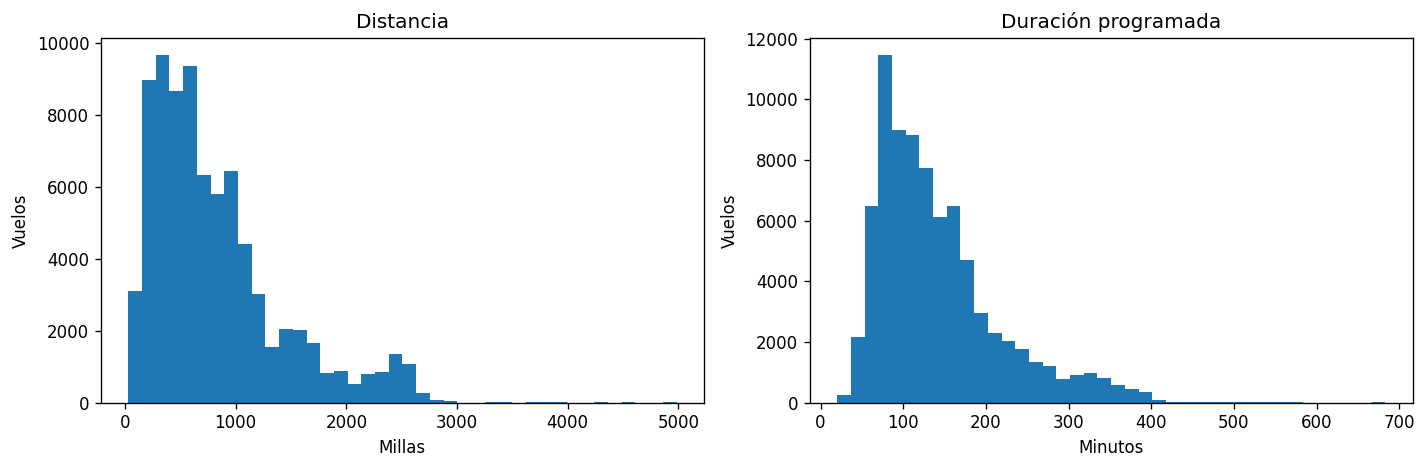

In [12]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
train.DISTANCE.plot.hist(bins=40, ax=axes[0])
train.SCHEDULED_TIME.plot.hist(bins=40, ax=axes[1])
axes[0].set(title='Distancia', xlabel='Millas', ylabel='Vuelos')
axes[1].set(title='Duración programada', xlabel='Minutos', ylabel='Vuelos')
plt.tight_layout(); plt.show()
print(train[['DISTANCE','SCHEDULED_TIME','SCHEDULED_DEPARTURE_MIN',OBJETIVO]].corr().round(3))

Distancia y duración tienen una correlación de 0.984. No se elimina automáticamente una de ellas. La necesidad de escalado depende del estimador y debe resolverse dentro del pipeline.

## 13. Preparar X e y sin fuga de información
Usamos una lista explícita de predictores. No se incluyen horas reales, causas del atraso, cancelación, desvío ni ARRIVAL_DELAY.

In [13]:
X_train = train[FEATURES]
y_train = train[OBJETIVO]
assert 'ARRIVAL_DELAY' not in X_train.columns
assert X_train.notna().all().all()
assert y_train.eq(train.ARRIVAL_DELAY.ge(15)).all()
print('X:', X_train.shape, '| y:', y_train.shape)
print('Comprobaciones de train: correctas')

X: (80000, 9) | y: (80000,)
Comprobaciones de train: correctas


## 14. Qué sigue para cumplir la tarea completa
1. Entrenar un pipeline de scikit-learn con ColumnTransformer, OneHotEncoder(handle_unknown="ignore") y un estimador.
2. Ajustar transformaciones y elegir hiperparámetros solo con train. Para regresión logística usar StandardScaler; para árboles puede omitirse.
3. Evaluar al final con test y reportar al menos dos métricas justificadas.
4. Guardar todo en model/model.pkl (<100 MB), verificar carga independiente y escribir model/metadata.json.
5. Crear requirements.txt, runtime.txt y Procfile del servicio; FastAPI con los endpoints requeridos.
6. Probar localhost, guardar evidencias y al menos tres tests; completar el repositorio con commits del equipo.

**Límites:** vuelos de 2015 que completan la ruta, aeropuertos con dos sistemas de códigos y partición aleatoria del mismo año.
La separación no demuestra desempeño en años futuros. El EDA y el archivo limpio no equivalen a una API terminada.

Para regenerar los archivos desde el original, ejecutar en la raíz del proyecto:
```powershell
python eda_limpieza.py --entrada "C:\ruta\flights.csv"
```
El detalle completo de decisiones está en `informe_eda.html`.